# Calcul de coefficients de polarisation

In [18]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [77]:
with open('Q174606.pickle', 'rb') as f:
    G = pickle.load(f)
G = G.to_undirected()

dico_periods = {}
for node in G.nodes():
    period = node.get_era()
    if period not in dico_periods:
        dico_periods[period] = [node]
    else:
        dico_periods[period].append(node)
del dico_periods['Unknown']

file = "Graphe"

In [75]:
with open('graphe_centroids_pot_seuil=1.3.pkl', 'rb') as f:
    G = pickle.load(f)
G = G.to_undirected()

def periode(str):
    try:
        date_deb = int(str[0:4])
        date_end = str[5:9]
        if date_deb is None :
            return "Unknown"
        elif date_deb < 1570 and date_deb > 476:
            return "Medieval"
        elif date_deb < 1730:
            return "Baroque"
        elif date_deb < 1800:
            return "Classique"
        elif date_deb < 1860:
            return "Romantique"
        else:
            try:
                date_end = int(date_end)
                return "XXe"
            except:
                return "contemporain"
    except :
        return "Unknown"
    
def dico_filenames(filename = "cross-era_annotations.csv"):
    dico = {}
    df = pd.read_csv(filename, sep=',')
    for i in range(len(df)):
        per = periode(df['CompLifetime'][i])
        print(df['Composer'][i],df['CompLifetime'][i],per)
        composer = df['Composer'][i]
        if per not in dico:
            dico[per] = [df['Composer'][i]]
        else:
            dico[per].append(df['Composer'][i])
    for key,item in dico.items():
        dico[key] = list(set(item))
    del dico['Unknown']
    return dico

dico_periods = dico_filenames()

file = "Chroma"

Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Albinoni; Tomaso 1671-1751 Baroque
Bach; Johann Sebastian 1685-1750 Baroque
Bach; Johann Sebastian 1685-1750 Baroque
Bach; Johann Sebastian 1685-1750 Baroque
Bach; Johann Sebastian 1685-1750 Baroque
Bach; Johann Sebastian 1685-175

## Version proposée par l'article "A Measure of Polarization on Social MediaNetworks Based on Community Boundaries"

In [78]:
def polarization_coefficient(period1,period2):
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    subgraph = G.subgraph(nodes1 + nodes2)
    B12 = set()
    B21 = set()
    I1 = set(nodes1)
    I2 = set(nodes2)
    for u in nodes1:
        for v in nodes2:
            if G.has_edge(u,v):
                B12.add(u)
                B21.add(v)
    I1 = I1 - B12
    I2 = I2 - B21
    s = 0
    for v in B12:
        di=0
        db = 0
        for w in subgraph.neighbors(v):
            if w in I1:
                di += 1
            elif w in B21:
                db += 1
        s += (di/(di+db)) - 0.5
    for v in B21:
        di=0
        db = 0
        for w in subgraph.neighbors(v):
            if w in I2:
                di += 1
            elif w in B12:
                db += 1
        s += (di/(di+db)) - 0.5
    if len(B12) + len(B21) == 0:
        return 0
    return s / (len(B12) + len(B21))

Text(0.5, 1.0, 'Polarization Coefficient Heatmap')

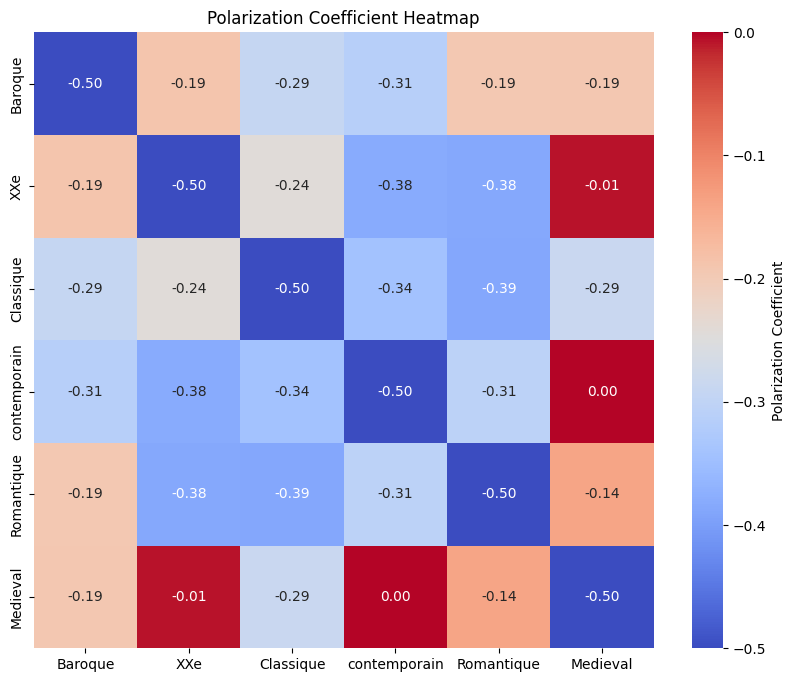

In [79]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = list(dico_periods.keys())
for i in range(len(periods)):
    for j in range(len(periods)):
            matrix[i][j] = polarization_coefficient(periods[i], periods[j])
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=periods, yticklabels=periods, cmap='coolwarm', cbar_kws={'label': 'Polarization Coefficient'})
plt.title('Polarization Coefficient Heatmap')

## Test de Fisher exact

In [80]:
from itertools import combinations
from scipy.stats import fisher_exact, chi2_contingency

In [81]:
def polarization_coefficient_fisher(period1, period2):
    """Utilise le teste de Fisher pour calculer le coefficient de polarisation entre deux périodes.
    H0 : En proportion, il y a autant de liens entre les deux périodes qu'à l'intérieur de chaque période."""
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    edges_AA = sum(1 for u, v in combinations(nodes1, 2) if G.has_edge(u, v))
    edges_BB = sum(1 for u, v in combinations(nodes2, 2) if G.has_edge(u, v))
    total_internal_edges = edges_AA + edges_BB

    inter_edges = sum(1 for u in nodes1 for v in nodes2 if G.has_edge(u, v))

    # Paires possibles
    total_internal_pairs = len(nodes1) * (len(nodes1) - 1) // 2 + \
                            len(nodes2) * (len(nodes2) - 1) // 2
    total_inter_pairs = len(nodes1) * len(nodes2)

    non_edges_internal = total_internal_pairs - total_internal_edges
    non_edges_inter = total_inter_pairs - inter_edges

    # Tableau 2x2
    table = np.array([
        [total_internal_edges, inter_edges],
        [non_edges_internal,   non_edges_inter]
    ])
    #print(table)
    res = fisher_exact(table, alternative="greater")
    return res.statistic

Text(0.5, 1.0, 'Polarization Coefficient Heatmap')

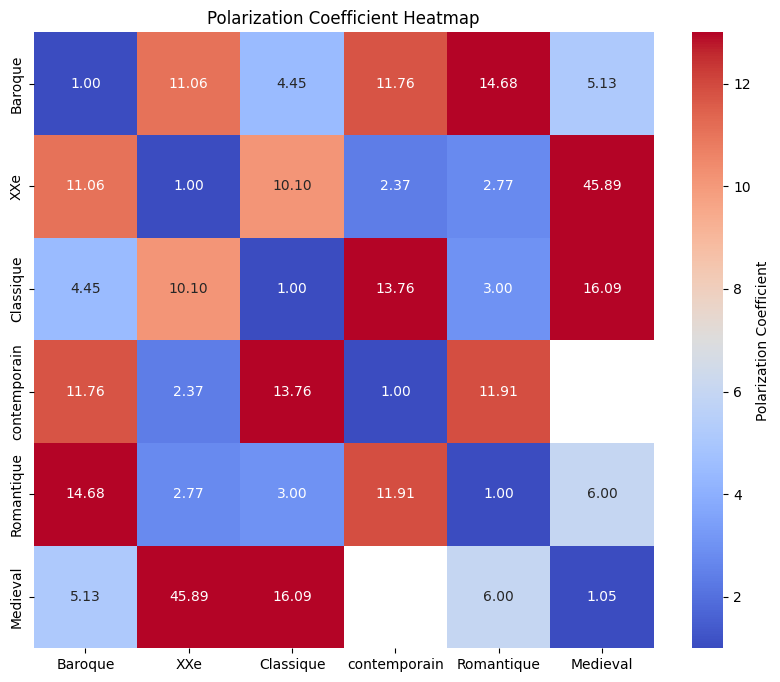

In [82]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = list(dico_periods.keys())
for i in range(len(periods)):
    for j in range(len(periods)):
            matrix[i][j] = polarization_coefficient_fisher(periods[i], periods[j])
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    xticklabels=periods,
    yticklabels=periods,
    cmap='coolwarm',
    vmin=1,
    vmax=13*(file=="Graphe") + 1*(file=="Chroma"),
    cbar_kws={'label': 'Polarization Coefficient'}
)
plt.title('Polarization Coefficient Heatmap')

### Un test alternatif : le test de Boschloo

In [83]:
def polarization_coefficient_chi2(period1, period2):
    """Utilise le teste de Fisher pour calculer le coefficient de polarisation entre deux périodes.
    H0 : En proportion, il y a autant de liens entre les deux périodes qu'à l'intérieur de chaque période."""
    nodes1 = dico_periods[period1]
    nodes2 = dico_periods[period2]
    edges_AA = sum(1 for u, v in combinations(nodes1, 2) if G.has_edge(u, v))
    edges_BB = sum(1 for u, v in combinations(nodes2, 2) if G.has_edge(u, v))
    total_internal_edges = edges_AA + edges_BB

    inter_edges = sum(1 for u in nodes1 for v in nodes2 if G.has_edge(u, v))

    # Paires possibles
    total_internal_pairs = len(nodes1) * (len(nodes1) - 1) // 2 + \
                            len(nodes2) * (len(nodes2) - 1) // 2
    total_inter_pairs = len(nodes1) * len(nodes2)

    non_edges_internal = total_internal_pairs - total_internal_edges
    non_edges_inter = total_inter_pairs - inter_edges

    # Tableau 2x2
    table = np.array([
        [total_internal_edges, inter_edges],
        [non_edges_internal,   non_edges_inter]
    ])
    #print(table)
    res = chi2_contingency(table)
    return res.statistic

Text(0.5, 1.0, 'Polarization Coefficient Heatmap')

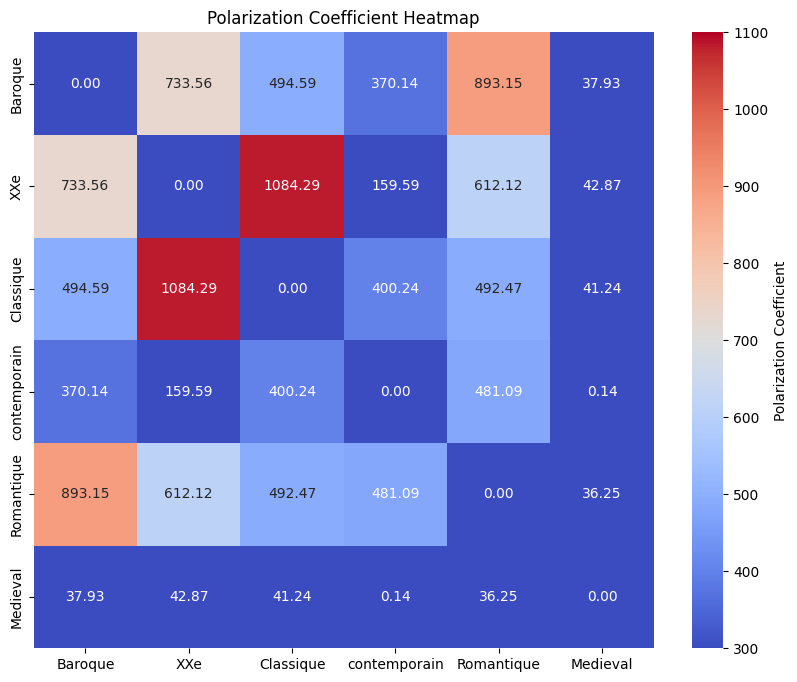

In [84]:
matrix = np.zeros((len(dico_periods), len(dico_periods)))
periods = list(dico_periods.keys())
for i in range(len(periods)):
    for j in range(len(periods)):
            matrix[i][j] = polarization_coefficient_chi2(periods[i], periods[j])
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt=".2f",
    xticklabels=periods,
    yticklabels=periods,
    cmap='coolwarm',
    vmin=300,
    vmax=1100,
    cbar_kws={'label': 'Polarization Coefficient'}
)
plt.title('Polarization Coefficient Heatmap')